# Implementing Logistic Regression with numpy

In this problem, you will need to write python codes and build logistic regression classifiers on breast cancer dataset to predict whether the cancer is malignant or benign on the patients. The dataset contains 569 samples and 30 features. You may refer to https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic) for more information about the dataset.

Your implementations should include:
- Load data, clean data and partition them into training and testing data.
- Build logistic regression and L2-regularized logistic regression models.
- Implement three gradient descent algorithms for each model: Batch Gradient Descent (GD), Mini-Batch Gradient Descent (MB-SGD) and Stochastic Gradient Descent (SGD).
- Compare the loss curve of three gradient descent algorithms (GD/MB-SGD/SGD).
- Compare logistic regression and regularized version in terms of training and testing error.
- Try to tune different parameters (regularization parameter, learning rate, etc.) to see their effects.

You could use sklearn or any other packages to load and process the data, but you can not directly use the package to train the model.


### Name: Mandar Sanju Bavdane


#### For this assignment, you will build 6 models. You need to train Logistic Regression/Regularized Logistic Regression each with Batch Gradient Descent, Stochastic Gradient Descent and Mini Batch Gradient Descent. Also you should plot their objective values versus epochs and compare their training and testing accuracies. You will need to tune the parameters a little bit to obtain reasonable results.

#### You do not have to follow the following procedure. You may implement your own functions and methods, but you need to show your results and plots.

In [240]:
# Load Packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Data processing

- Download the Breast Cancer dataset from canvas or from https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)
- Load the data.
- Preprocess the data.

## 1.1. Load the data

In [241]:
df = pd.read_csv('data.csv', header=None)
print(df.shape)
df.head()

(569, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1.2 Examine and clean data

In [242]:
# Some columns may not be useful for the model (For example, the first column contains ID number which may be irrelavant). 
# You need to get rid of the ID number feature.
# Also you should transform target labels in the second column from 'B' and 'M' to 1 and -1.

# Drop the ID column
df = df.drop(columns=[0])

# Map labels: B -> 1, M -> -1
y = df[1].map({'B': 1, 'M': -1}).values.reshape(-1, 1)
x = df.drop(columns=[1])

print('Missing values:', x.isnull().sum().sum())
print('x shape:', x.shape, ' y shape:', y.shape)
print('Benign:', np.sum(y == 1), ' Malignant:', np.sum(y == -1))



Missing values: 0
x shape: (569, 30)  y shape: (569, 1)
Benign: 357  Malignant: 212


In [243]:
print(df.shape)
df.sample(5)

(569, 31)


,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
387,B,13.880,16.16,88.37,596.6,0.07026,0.04831,0.02045,0.008507,0.1607,...,15.510,19.97,99.66,745.3,0.08484,0.12330,0.10910,0.04537,0.2542,0.06623
357,B,13.870,16.21,88.52,593.7,0.08743,0.05492,0.01502,0.020880,0.1424,...,15.110,25.58,96.74,694.4,0.11530,0.10080,0.05285,0.05556,0.2362,0.07113
151,B,8.219,20.70,53.27,203.9,0.09405,0.13050,0.13210,0.021680,0.2222,...,9.092,29.72,58.08,249.8,0.16300,0.43100,0.53810,0.07879,0.3322,0.14860
311,B,14.610,15.69,92.68,664.9,0.07618,0.03515,0.01447,0.018770,0.1632,...,16.460,21.75,103.70,840.8,0.10110,0.07087,0.04746,0.05813,0.2530,0.05695
459,B,9.755,28.20,61.68,290.9,0.07984,0.04626,0.01541,0.010430,0.1621,...,10.670,36.92,68.03,349.9,0.11100,0.11090,0.07190,0.04866,0.2321,0.07211


## 1.3. Partition to training and testing sets

In [244]:
# You can partition using 80% training data and 20% testing data. It is a commonly used ratio in machinel learning.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', x_train.shape, y_train.shape)
print('Test: ', x_test.shape, y_test.shape)


Train: (455, 30) (455, 1)
Test:  (114, 30) (114, 1)


## 1.4. Feature scaling

Use the standardization to trainsform both training and test features

In [245]:
# Standardization
import numpy

# calculate mu and sig using the training set
d = x_train.shape[1]
mu = numpy.mean(x_train.values, axis=0).reshape(1, d)
sig = numpy.std(x_train.values, axis=0).reshape(1, d)

# transform the training features
x_train = (x_train - mu) / (sig + 1E-6)

# transform the test features
x_test = (x_test - mu) / (sig + 1E-6)

print('test mean = ')
print(numpy.mean(x_test, axis=0))

print('test std = ')
print(numpy.std(x_test, axis=0))

test mean = 
2     0.085785
3     0.047963
4     0.085170
5     0.091955
6     0.071599
7     0.044072
8    -0.024083
9     0.073835
10    0.096790
11   -0.015471
12    0.115674
13   -0.016400
14    0.110162
15    0.130811
16   -0.067993
17   -0.016191
18   -0.101685
19    0.097981
20   -0.134843
21   -0.004276
22    0.096334
23    0.024020
24    0.095722
25    0.104435
26    0.008790
27   -0.001985
28   -0.101576
29    0.052514
30   -0.061058
31    0.000326
dtype: float64
test std = 
2     1.032942
3     0.875678
4     1.028845
5     1.095109
6     1.207493
7     0.932317
8     0.870138
9     0.983166
10    0.873264
11    0.929812
12    1.162558
13    0.812857
14    1.113700
15    1.385546
16    0.764185
17    0.839296
18    0.585474
19    0.898015
20    0.660841
21    0.729293
22    1.062085
23    0.935670
24    1.057461
25    1.137826
26    1.061984
27    0.918942
28    0.813318
29    0.918669
30    0.763044
31    0.903282
dtype: float64


In [246]:
# convert to numpy arrays for the rest of the notebook
x_train = np.asarray(x_train)
x_test = np.asarray(x_test)

# 2.  Logistic Regression Model

The objective function is $Q (w; X, y) = \frac{1}{n} \sum_{i=1}^n \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $.

When $\lambda = 0$, the model is a regular logistric regression and when $\lambda > 0$, it essentially becomes a regularized logistric regression.

In [247]:
# Calculate the objective function value, or loss
# Inputs:
#     w: weight: d-by-1 vector
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: regularization parameter: scalar
# Return:
#     objective function value, or loss (scalar)
def objective(w, x, y, lam):
    yxw = y * np.dot(x, w)                 # n-by-1: y_i * x_i^T w
    loss = np.mean(np.logaddexp(0, -yxw))  # (1/n) * sum log(1 + exp(-y_i x_i^T w))
    reg = lam / 2 * np.sum(w * w)          # (lam/2) * ||w||^2
    return loss + reg

In [248]:
w0 = np.zeros((d, 1))
print(objective(w0, x_train, y_train, 0))

0.6931471805599453


# 3. Numerical optimization

## 3.1. Gradient descent


The gradient at $w$ for regularized logistic regression is  $g = - \frac{1}{n} \sum_{i=1}^n \frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$

In [249]:
# Calculate the gradient
# Inputs:
#     w: weight: d-by-1 matrix
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: regularization parameter: scalar
# Return:
#     g: gradient: d-by-1 matrix

def gradient(w, x, y, lam):
    yxw = y * np.dot(x, w)                                    # n-by-1
    coef = -y / (1 + np.exp(yxw))                             # n-by-1: -y_i / (1 + exp(y_i x_i^T w))
    g = np.mean(coef * x, axis=0).reshape(-1, 1) + lam * w    # d-by-1
    return g

In [250]:
# Gradient descent for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 vector, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 vector, the solution
#     objvals: a record of each epoch's objective value

def gradient_descent(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = np.zeros(max_epoch)
    for t in range(max_epoch):
        g = gradient(w, x, y, lam)
        w = w - learning_rate * g
        objvals[t] = objective(w, x, y, lam)
        print(f'Objective value at epoch t={t} is {objvals[t]:.6f}')
    return w, objvals

Use gradient_descent function to obtain your optimal weights and a list of objective values over each epoch.

In [251]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
lam = 0
w_init = np.zeros((d, 1))
learning_rate = 1.0
w_gd, objvals_gd = gradient_descent(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.171292
Objective value at epoch t=1 is 0.135307
Objective value at epoch t=2 is 0.117950
Objective value at epoch t=3 is 0.110070
Objective value at epoch t=4 is 0.105148
Objective value at epoch t=5 is 0.101332
Objective value at epoch t=6 is 0.098154
Objective value at epoch t=7 is 0.095425
Objective value at epoch t=8 is 0.093040
Objective value at epoch t=9 is 0.090929
Objective value at epoch t=10 is 0.089043
Objective value at epoch t=11 is 0.087345
Objective value at epoch t=12 is 0.085806
Objective value at epoch t=13 is 0.084401
Objective value at epoch t=14 is 0.083114
Objective value at epoch t=15 is 0.081927
Objective value at epoch t=16 is 0.080830
Objective value at epoch t=17 is 0.079811
Objective value at epoch t=18 is 0.078861
Objective value at epoch t=19 is 0.077973
Objective value at epoch t=20 is 0.077140
Objective value at epoch t=21 is 0.076357
Objective value at epoch t=22 is 0.075618
Objective value at epoch t=23 is 0.074921
Ob

In [252]:
# Train Regularized Logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
lam = 1E-2
w_init = np.zeros((d, 1))
learning_rate = 1.0
w_gd_reg, objvals_gd_reg = gradient_descent(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.181445
Objective value at epoch t=1 is 0.145987
Objective value at epoch t=2 is 0.129994
Objective value at epoch t=3 is 0.123514
Objective value at epoch t=4 is 0.119800
Objective value at epoch t=5 is 0.117067
Objective value at epoch t=6 is 0.114882
Objective value at epoch t=7 is 0.113073
Objective value at epoch t=8 is 0.111547
Objective value at epoch t=9 is 0.110242
Objective value at epoch t=10 is 0.109116
Objective value at epoch t=11 is 0.108137
Objective value at epoch t=12 is 0.107279
Objective value at epoch t=13 is 0.106523
Objective value at epoch t=14 is 0.105853
Objective value at epoch t=15 is 0.105256
Objective value at epoch t=16 is 0.104722
Objective value at epoch t=17 is 0.104243
Objective value at epoch t=18 is 0.103810
Objective value at epoch t=19 is 0.103419
Objective value at epoch t=20 is 0.103064
Objective value at epoch t=21 is 0.102741
Objective value at epoch t=22 is 0.102446
Objective value at epoch t=23 is 0.102175
Ob

## 3.2. Stochastic gradient descent (SGD)

Define new objective function $Q_i (w) = \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $. 

The stochastic gradient at $w$ is $g_i = \frac{\partial Q_i }{ \partial w} = -\frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [253]:
# Calculate the objective Q_i and the gradient of Q_i
# Inputs:
#     w: weights: d-by-1 matrix
#     xi: data: 1-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 matrix, gradient of Q_i

def stochastic_objective_gradient(w, xi, yi, lam):
    yxw = (yi * np.dot(xi, w)).item()                                # scalar: y_i x_i^T w
    obj = np.logaddexp(0, -yxw) + lam / 2 * np.sum(w * w)            # Q_i
    g = (-yi / (1 + np.exp(yxw))) * xi.reshape(-1, 1) + lam * w      # d-by-1
    return obj, g

Hints:
1. In every epoch, randomly permute the $n$ samples.
2. Each epoch has $n$ iterations. In every iteration, use 1 sample, and compute the gradient and objective using the ``stochastic_objective_gradient`` function. In the next iteration, use the next sample, and so on.

In [254]:
# SGD for solving logistic regression
# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 matrix, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 matrix, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

def sgd(x, y, lam, learning_rate, w, max_epoch=100):
    n = x.shape[0]
    objvals = np.zeros(max_epoch)
    for t in range(max_epoch):
        # randomly permute the n samples
        rand_indices = np.random.permutation(n)
        x_rand = x[rand_indices, :]
        y_rand = y[rand_indices, :]

        objval = 0
        for i in range(n):
            xi = x_rand[i, :].reshape(1, -1)   # 1-by-d
            yi = float(y_rand[i, 0])           # scalar
            obj, g = stochastic_objective_gradient(w, xi, yi, lam)
            objval += obj
            w = w - learning_rate * g

        learning_rate *= 0.9                   # decrease learning rate each epoch
        objvals[t] = objval / n                # average Q_i over the epoch
        print(f'Objective value at epoch t={t} is {objvals[t]:.6f}')
    return w, objvals

Use sgd function to obtain your optimal weights and a list of objective values over each epoch.

In [255]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 0
w_init = np.zeros((d, 1))
learning_rate = 0.1
w_sgd, objvals_sgd = sgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.117488
Objective value at epoch t=1 is 0.066252
Objective value at epoch t=2 is 0.063744
Objective value at epoch t=3 is 0.056699
Objective value at epoch t=4 is 0.057362
Objective value at epoch t=5 is 0.054283
Objective value at epoch t=6 is 0.053218
Objective value at epoch t=7 is 0.051749
Objective value at epoch t=8 is 0.051554
Objective value at epoch t=9 is 0.050256
Objective value at epoch t=10 is 0.049998
Objective value at epoch t=11 is 0.049484
Objective value at epoch t=12 is 0.048681
Objective value at epoch t=13 is 0.048343
Objective value at epoch t=14 is 0.048127
Objective value at epoch t=15 is 0.047844
Objective value at epoch t=16 is 0.047316
Objective value at epoch t=17 is 0.047258
Objective value at epoch t=18 is 0.047013
Objective value at epoch t=19 is 0.046792
Objective value at epoch t=20 is 0.046610
Objective value at epoch t=21 is 0.046463
Objective value at epoch t=22 is 0.046334
Objective value at epoch t=23 is 0.046172
Ob

In [256]:
# Train regularized logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 1E-2
w_init = np.zeros((d, 1))
learning_rate = 0.1
w_sgd_reg, objvals_sgd_reg = sgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.141518
Objective value at epoch t=1 is 0.106543
Objective value at epoch t=2 is 0.107615
Objective value at epoch t=3 is 0.105152
Objective value at epoch t=4 is 0.105192
Objective value at epoch t=5 is 0.103907
Objective value at epoch t=6 is 0.103211
Objective value at epoch t=7 is 0.102417
Objective value at epoch t=8 is 0.102243
Objective value at epoch t=9 is 0.101691
Objective value at epoch t=10 is 0.101818
Objective value at epoch t=11 is 0.101392
Objective value at epoch t=12 is 0.100680
Objective value at epoch t=13 is 0.100265
Objective value at epoch t=14 is 0.100622
Objective value at epoch t=15 is 0.099819
Objective value at epoch t=16 is 0.099831
Objective value at epoch t=17 is 0.099770
Objective value at epoch t=18 is 0.099646
Objective value at epoch t=19 is 0.099396
Objective value at epoch t=20 is 0.099324
Objective value at epoch t=21 is 0.099208
Objective value at epoch t=22 is 0.099067
Objective value at epoch t=23 is 0.098949
Ob

## 3.3 Mini-Batch Gradient Descent (MBGD)

Define $Q_I (w) = \frac{1}{b} \sum_{i \in I} \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $, where $I$ is a set containing $b$ indices randomly drawn from $\{ 1, \cdots , n \}$ without replacement.

The stochastic gradient at $w$ is $g_I = \frac{\partial Q_I }{ \partial w} = \frac{1}{b} \sum_{i \in I} \frac{- y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [257]:
# Calculate the objective Q_I and the gradient of Q_I
# Inputs:
#     w: weights: d-by-b matrix
#     xi: data: b-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 matrix, gradient of Q_i

def mb_objective_gradient(w, xi, yi, lam):
    yxw = yi * np.dot(xi, w)                                          # b-by-1
    obj = np.mean(np.logaddexp(0, -yxw)) + lam / 2 * np.sum(w * w)    # Q_I
    coef = -yi / (1 + np.exp(yxw))                                    # b-by-1
    g = np.mean(coef * xi, axis=0).reshape(-1, 1) + lam * w           # d-by-1
    return obj, g

Hints:
1. In every epoch, randomly permute the $n$ samples (just like SGD).
2. Each epoch has $\frac{n}{b}$ iterations. In every iteration, use $b$ samples, and compute the gradient and objective using the ``mb_objective_gradient`` function. In the next iteration, use the next $b$ samples, and so on.

In [258]:
# MBGD for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 matrix, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 matrix, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

batch_size = 8

def mbgd(x, y, lam, learning_rate, w, max_epoch=100):
    n = x.shape[0]
    num_batches = int(np.ceil(n / batch_size))
    objvals = np.zeros(max_epoch)
    for t in range(max_epoch):
        # randomly permute the n samples
        rand_indices = np.random.permutation(n)
        x_rand = x[rand_indices, :]
        y_rand = y[rand_indices, :]

        objval = 0
        for i in range(num_batches):
            xi = x_rand[i * batch_size:(i + 1) * batch_size, :]   # b-by-d
            yi = y_rand[i * batch_size:(i + 1) * batch_size, :]   # b-by-1
            obj, g = mb_objective_gradient(w, xi, yi, lam)
            objval += obj
            w = w - learning_rate * g

        learning_rate *= 0.9                  # decrease learning rate each epoch
        objvals[t] = objval / num_batches     # average Q_I over the epoch
        print(f'Objective value at epoch t={t} is {objvals[t]:.6f}')
    return w, objvals

Use mbgd function to obtain your optimal weights and a list of objective values over each epoch.

In [259]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 0
w_init = np.zeros((d, 1))
learning_rate = 0.5
w_mbgd, objvals_mbgd = mbgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.131229
Objective value at epoch t=1 is 0.072289
Objective value at epoch t=2 is 0.066932
Objective value at epoch t=3 is 0.061046
Objective value at epoch t=4 is 0.059605
Objective value at epoch t=5 is 0.056935
Objective value at epoch t=6 is 0.055907
Objective value at epoch t=7 is 0.055252
Objective value at epoch t=8 is 0.053943
Objective value at epoch t=9 is 0.053053
Objective value at epoch t=10 is 0.052217
Objective value at epoch t=11 is 0.052024
Objective value at epoch t=12 is 0.051511
Objective value at epoch t=13 is 0.051039
Objective value at epoch t=14 is 0.050767
Objective value at epoch t=15 is 0.050386
Objective value at epoch t=16 is 0.050070
Objective value at epoch t=17 is 0.049820
Objective value at epoch t=18 is 0.049698
Objective value at epoch t=19 is 0.049468
Objective value at epoch t=20 is 0.049310
Objective value at epoch t=21 is 0.049166
Objective value at epoch t=22 is 0.049053
Objective value at epoch t=23 is 0.048874
Ob

In [260]:
# Train Regularized Logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 1E-2
w_init = np.zeros((d, 1))
learning_rate = 0.5
w_mbgd_reg, objvals_mbgd_reg = mbgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.149870
Objective value at epoch t=1 is 0.105410
Objective value at epoch t=2 is 0.105243
Objective value at epoch t=3 is 0.102683
Objective value at epoch t=4 is 0.102480
Objective value at epoch t=5 is 0.101170
Objective value at epoch t=6 is 0.101384
Objective value at epoch t=7 is 0.101461
Objective value at epoch t=8 is 0.100653
Objective value at epoch t=9 is 0.100352
Objective value at epoch t=10 is 0.100102
Objective value at epoch t=11 is 0.100058
Objective value at epoch t=12 is 0.099730
Objective value at epoch t=13 is 0.099513
Objective value at epoch t=14 is 0.099657
Objective value at epoch t=15 is 0.099122
Objective value at epoch t=16 is 0.099064
Objective value at epoch t=17 is 0.098969
Objective value at epoch t=18 is 0.098944
Objective value at epoch t=19 is 0.098792
Objective value at epoch t=20 is 0.098695
Objective value at epoch t=21 is 0.098637
Objective value at epoch t=22 is 0.098627
Objective value at epoch t=23 is 0.098494
Ob

Objective value at epoch t=25 is 0.098544
Objective value at epoch t=26 is 0.098396
Objective value at epoch t=27 is 0.098303
Objective value at epoch t=28 is 0.098192
Objective value at epoch t=29 is 0.098343
Objective value at epoch t=30 is 0.098241
Objective value at epoch t=31 is 0.098495
Objective value at epoch t=32 is 0.098291
Objective value at epoch t=33 is 0.098061
Objective value at epoch t=34 is 0.098054
Objective value at epoch t=35 is 0.098159
Objective value at epoch t=36 is 0.098037
Objective value at epoch t=37 is 0.099268
Objective value at epoch t=38 is 0.098479
Objective value at epoch t=39 is 0.098088
Objective value at epoch t=40 is 0.098005
Objective value at epoch t=41 is 0.098033
Objective value at epoch t=42 is 0.098030
Objective value at epoch t=43 is 0.098170
Objective value at epoch t=44 is 0.097953
Objective value at epoch t=45 is 0.098479
Objective value at epoch t=46 is 0.098029
Objective value at epoch t=47 is 0.097940
Objective value at epoch t=48 is 0

# 4. Compare GD, SGD, MBGD

### Plot objective function values against epochs.

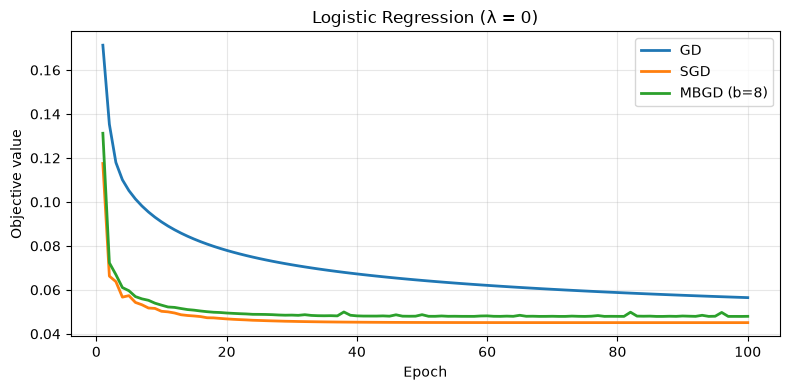

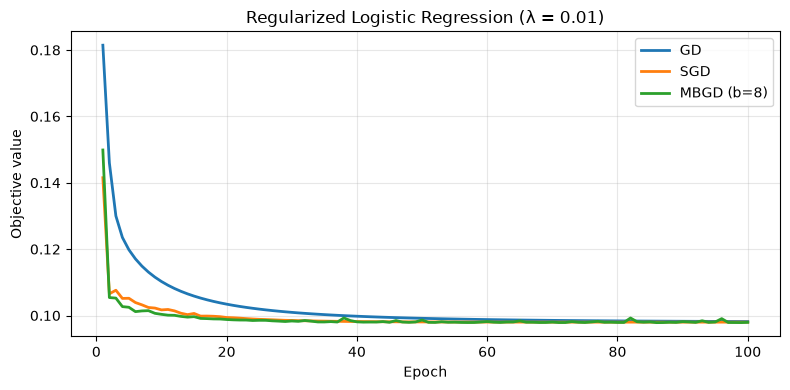

In [261]:
import matplotlib.pyplot as plt
%matplotlib inline

epochs = np.arange(1, 101)

# Logistic regression (lam = 0)
fig = plt.figure(figsize=(8, 4))
plt.plot(epochs, objvals_gd, label='GD', linewidth=2)
plt.plot(epochs, objvals_sgd, label='SGD', linewidth=2)
plt.plot(epochs, objvals_mbgd, label='MBGD (b=8)', linewidth=2)
plt.title('Logistic Regression (λ = 0)')
plt.xlabel('Epoch')
plt.ylabel('Objective value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Regularized logistic regression (lam = 0.01)
fig = plt.figure(figsize=(8, 4))
plt.plot(epochs, objvals_gd_reg, label='GD', linewidth=2)
plt.plot(epochs, objvals_sgd_reg, label='SGD', linewidth=2)
plt.plot(epochs, objvals_mbgd_reg, label='MBGD (b=8)', linewidth=2)
plt.title('Regularized Logistic Regression (λ = 0.01)')
plt.xlabel('Epoch')
plt.ylabel('Objective value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Comparison of GD, SGD and MBGD:**
- SGD and MBGD reduce the objective much faster per epoch than batch GD, because they make many updates per epoch (455 for SGD, 57 for MBGD with b = 8) versus a single update for GD.
- For plain logistic regression (λ = 0), GD is still decreasing slowly at epoch 100 (0.0565), while SGD (0.0451) and MBGD (0.0480) have already leveled off at a lower value.
- For regularized logistic regression (λ = 0.01), all three methods converge to the same minimum (about 0.098), since the regularized objective has a unique solution. GD takes about 40 epochs to get there; SGD and MBGD take about 10.
- GD gives the smoothest curve. SGD and MBGD curves have small bumps because each update uses only a random subset of the data.
- Note: GD records the full training objective after each epoch, while SGD and MBGD record the average batch loss during the epoch.

# 5. Prediction
### Compare the training and testing accuracy for logistic regression and regularized logistic regression.

In [262]:
# Predict class label
# Inputs:
#     w: weights: d-by-1 matrix
#     X: data: m-by-d matrix
# Return:
#     f: m-by-1 matrix, the predictions

def predict(w, X):
    xw = np.dot(X, w)        # m-by-1
    f = np.sign(xw)          # +1 (benign) or -1 (malignant)
    f[f == 0] = 1            # break ties (xw exactly 0) as benign
    return f

In [263]:
def calculate_error(w, x, y):
    y_pred = predict(w,x)
    score = np.mean(y != y_pred)
    return score

In [264]:
# evaluate training error of logistic regression and regularized version
models = {
    'GD':        w_gd,     'GD (reg)':   w_gd_reg,
    'SGD':       w_sgd,    'SGD (reg)':  w_sgd_reg,
    'MBGD':      w_mbgd,   'MBGD (reg)': w_mbgd_reg,
}

print('Training error:')
for name, w in models.items():
    train_err = np.mean(predict(w, x_train) != y_train)
    print(f'  {name:<12} {train_err:.4f}   (accuracy {1 - train_err:.4f})')

Training error:
  GD           0.0132   (accuracy 0.9868)
  GD (reg)     0.0132   (accuracy 0.9868)
  SGD          0.0110   (accuracy 0.9890)
  SGD (reg)    0.0110   (accuracy 0.9890)
  MBGD         0.0110   (accuracy 0.9890)
  MBGD (reg)   0.0110   (accuracy 0.9890)


In [265]:
# evaluate testing error of logistic regression and regularized version
print('Testing error:')
for name, w in models.items():
    test_err = np.mean(predict(w, x_test) != y_test)
    print(f'  {name:<12} {test_err:.4f}   (accuracy {1 - test_err:.4f})')

Testing error:
  GD           0.0351   (accuracy 0.9649)
  GD (reg)     0.0351   (accuracy 0.9649)
  SGD          0.0351   (accuracy 0.9649)
  SGD (reg)    0.0351   (accuracy 0.9649)
  MBGD         0.0351   (accuracy 0.9649)
  MBGD (reg)   0.0351   (accuracy 0.9649)


**Comparison of logistic regression and regularized logistic regression:**
- Training accuracy is 98.68% (GD) and 98.90% (SGD, MBGD) for both the regular and regularized models.
- Testing accuracy is 96.49% for all six models (4 of 114 test samples misclassified).
- With λ = 0.01, regularization does not change the training or testing error. The dataset has many more samples (455) than features (30) and the features are standardized, so the unregularized model does not overfit much. The small gap between training error (~1.1%) and testing error (~3.5%) confirms this.
- The choice of optimizer affects convergence speed but not the final accuracy.

# 6. Parameters tuning

### In this section, you may try different combinations of parameters (regularization value, learning rate, etc) to see their effects on the model.

### 1. Setup and Validaton

In [274]:
import time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# silence the per-epoch prints of the training functions
import contextlib, io
def quiet(f, *args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return f(*args, **kwargs)

def error_rate(w, X, y):
    return np.mean(predict(w, X) != y)

def log_loss(w, X, y):
    return objective(w, X, y, 0)          # pure logistic loss (lam = 0), comparable across lambdas

# Hold out 20% of the TRAINING data as a validation set, so hyperparameters are chosen
# without ever looking at the test set.
rng = np.random.RandomState(7)
perm = rng.permutation(x_train.shape[0])
n_val = int(0.2 * len(perm))
val_idx, fit_idx = perm[:n_val], perm[n_val:]
x_fit, y_fit = x_train[fit_idx], y_train[fit_idx]
x_val, y_val = x_train[val_idx], y_train[val_idx]
print('fit:', x_fit.shape, ' validation:', x_val.shape, ' test (untouched):', x_test.shape)

fit: (364, 30)  validation: (91, 30)  test (untouched): (114, 30)


### 2. Grid search over (lambda, learning rate) with batch GD


Validation log-loss (GD, 300 epochs)


lr,0.01,0.10,0.50,1.00
lambda,,,,
0.000,0.1305,0.0531,0.0395,0.0520
0.001,0.1307,0.0539,0.0407,0.0471
0.010,0.1324,0.0608,0.0533,0.0533
0.100,0.1492,0.1131,0.1130,0.1130
0.300,0.1849,0.1734,0.1734,0.1734


Validation error (GD, 300 epochs)


lr,0.01,0.10,0.50,1.00
lambda,,,,
0.000,0.033,0.011,0.000,0.022
0.001,0.033,0.011,0.000,0.022
0.010,0.033,0.011,0.000,0.000
0.100,0.033,0.022,0.022,0.022
0.300,0.033,0.022,0.022,0.022


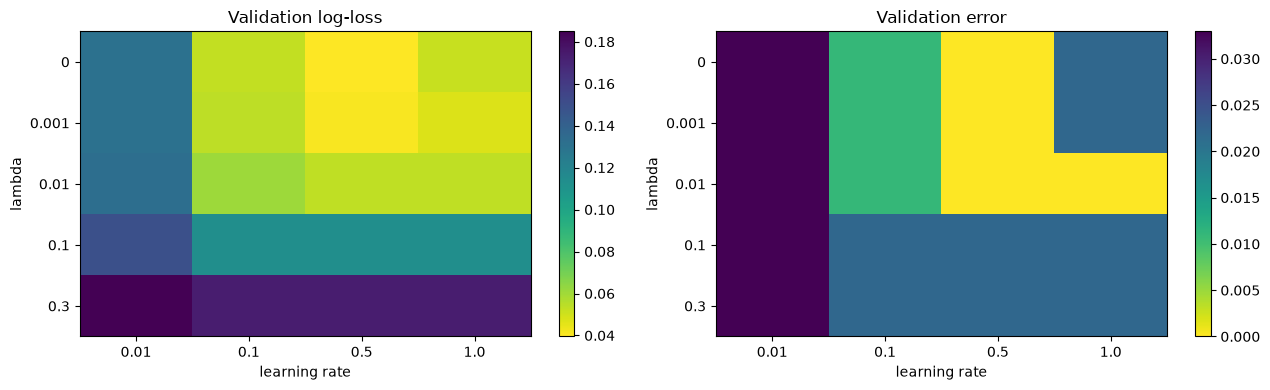

Best GD setting on validation data: lambda = 0, lr = 0.5


In [ ]:
lam_grid = [0, 1e-3, 1e-2, 1e-1, 0.3]
lr_grid  = [0.01, 0.1, 0.5, 1.0]

val_loss = pd.DataFrame(index=lam_grid, columns=lr_grid, dtype=float)
val_err  = pd.DataFrame(index=lam_grid, columns=lr_grid, dtype=float)

for lam, lr in itertools.product(lam_grid, lr_grid):
    w, _ = quiet(gradient_descent, x_fit, y_fit, lam, lr, np.zeros((d, 1)), max_epoch=300)
    val_loss.loc[lam, lr] = log_loss(w, x_val, y_val)
    val_err.loc[lam, lr]  = error_rate(w, x_val, y_val)

val_loss.index.name, val_loss.columns.name = 'lambda', 'lr'
val_err.index.name,  val_err.columns.name  = 'lambda', 'lr'
print('Validation log-loss (GD, 300 epochs)'); display(val_loss.round(4))
print('Validation error (GD, 300 epochs)');    display(val_err.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, table, title in zip(axes, [val_loss, val_err], ['Validation log-loss', 'Validation error']):
    im = ax.imshow(table.values.astype(float), cmap='viridis_r', aspect='auto')
    ax.set_xticks(range(len(lr_grid)));  ax.set_xticklabels(lr_grid)
    ax.set_yticks(range(len(lam_grid))); ax.set_yticklabels(lam_grid)
    ax.set_xlabel('learning rate'); ax.set_ylabel('lambda'); ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# best cell = lowest validation log-loss (error ties are common on small validation sets)
best_lam, best_lr = np.unravel_index(np.argmin(val_loss.values.astype(float)), val_loss.shape)
best_lam, best_lr = lam_grid[best_lam], lr_grid[best_lr]
print(f'Best GD setting on validation data: lambda = {best_lam}, lr = {best_lr}')

### 3. Effect of lambda on the weights and accuracy


,train err,test err,||w||,#weights |w|>0.1
lambda,,,,
0.0000,0.0110,0.0351,4.1397,29
0.0001,0.0110,0.0351,4.0963,29
0.0010,0.0110,0.0351,3.7540,29
0.0100,0.0110,0.0351,2.3941,28
0.1000,0.0220,0.0439,1.1640,21
1.0000,0.0418,0.0526,0.4560,8


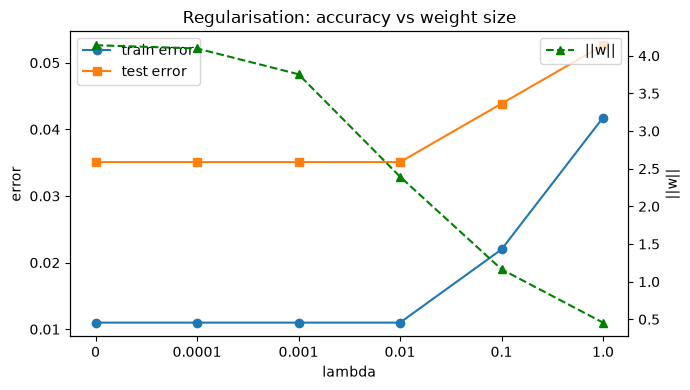

In [ ]:
lams = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
rows = []
for lam in lams:
    w, _ = quiet(gradient_descent, x_train, y_train, lam, 0.5, np.zeros((d, 1)), max_epoch=500)
    rows.append({'lambda': lam,
                 'train err': error_rate(w, x_train, y_train),
                 'test err':  error_rate(w, x_test,  y_test),
                 '||w||':     np.linalg.norm(w),
                 '#weights |w|>0.1': int(np.sum(np.abs(w) > 0.1))})
lam_df = pd.DataFrame(rows).set_index('lambda')
display(lam_df.round(4))

fig, ax1 = plt.subplots(figsize=(7, 4))
xs = np.arange(len(lams))
ax1.plot(xs, lam_df['train err'], 'o-', label='train error')
ax1.plot(xs, lam_df['test err'],  's-', label='test error')
ax1.set_xticks(xs); ax1.set_xticklabels([str(l) for l in lams])
ax1.set_xlabel('lambda'); ax1.set_ylabel('error'); ax1.legend(loc='upper left')
ax2 = ax1.twinx(); ax2.plot(xs, lam_df['||w||'], 'g--^', label='||w||'); ax2.set_ylabel('||w||')
ax2.legend(loc='upper right'); plt.title('Regularisation: accuracy vs weight size'); plt.tight_layout(); plt.show()

### 4. Learning Rate sensitivity of GD, SGD and MBGD

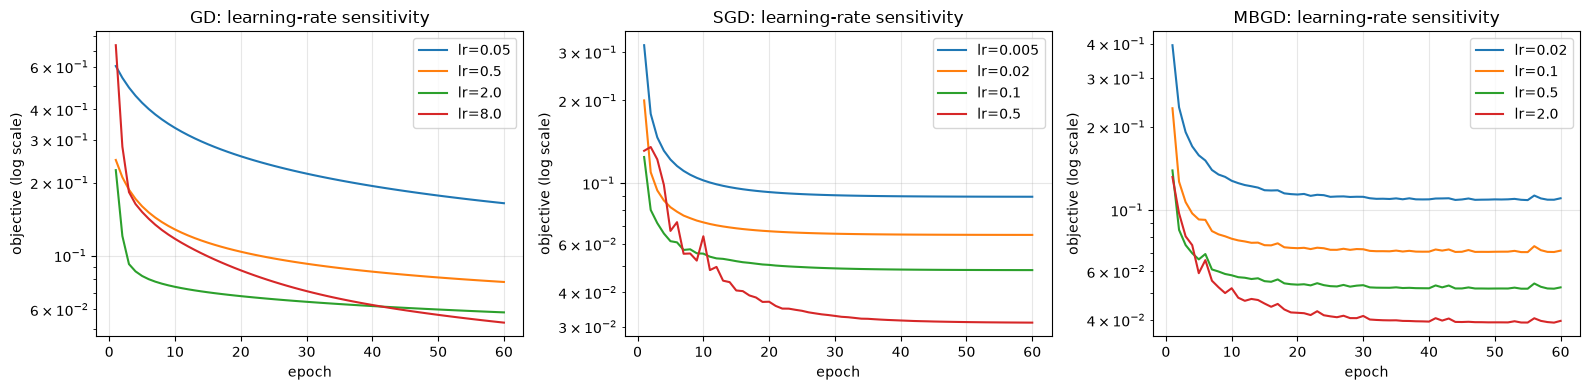

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lr_sets = {'GD': [0.05, 0.5, 2.0, 8.0], 'SGD': [0.005, 0.02, 0.1, 0.5], 'MBGD': [0.02, 0.1, 0.5, 2.0]}
for ax, (name, lrs) in zip(axes, lr_sets.items()):
    for lr in lrs:
        np.random.seed(0)
        if name == 'GD':
            _, ov = quiet(gradient_descent, x_fit, y_fit, best_lam, lr, np.zeros((d, 1)), max_epoch=60)
        elif name == 'SGD':
            _, ov = quiet(sgd, x_fit, y_fit, best_lam, lr, np.zeros((d, 1)), max_epoch=60)
        else:
            _, ov = quiet(mbgd, x_fit, y_fit, best_lam, lr, np.zeros((d, 1)), max_epoch=60)
        ax.plot(np.arange(1, 61), ov, label=f'lr={lr}')
    ax.set_yscale('log'); ax.set_title(f'{name}: learning-rate sensitivity')
    ax.set_xlabel('epoch'); ax.set_ylabel('objective (log scale)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5. Mini Batch Size per epoch per second

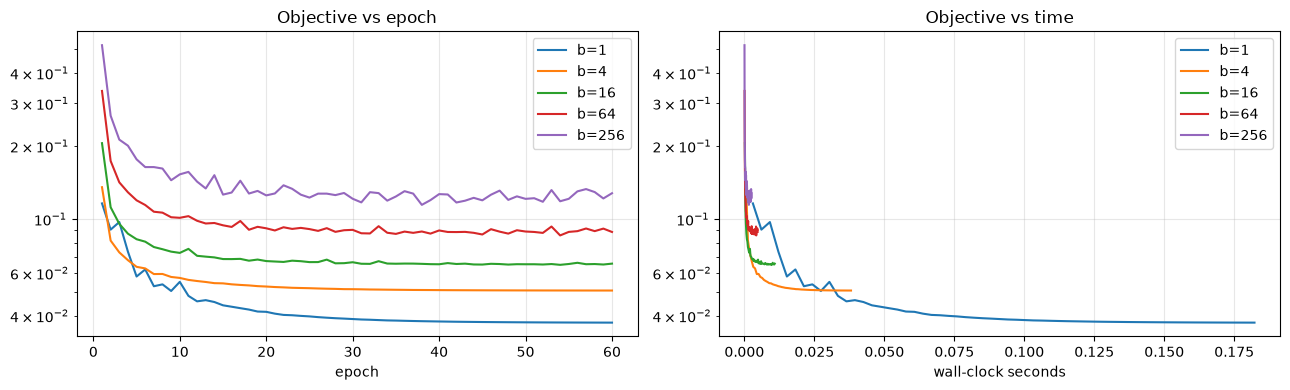

,updates/epoch,final objective,val err,seconds (60 ep)
batch size,,,,
1,364,0.0375,0.022,0.1822
4,91,0.0508,0.022,0.0381
16,23,0.0655,0.000,0.0108
64,6,0.0885,0.011,0.0047
256,2,0.1278,0.022,0.0025


In [ ]:
sizes = [1, 4, 16, 64, 256]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rows = []
for b in sizes:
    batch_size = b                      # mbgd reads this module-level setting
    np.random.seed(0)
    t0 = time.time()
    w, ov = quiet(mbgd, x_fit, y_fit, best_lam, 0.3, np.zeros((d, 1)), max_epoch=60)
    secs = time.time() - t0
    axes[0].plot(np.arange(1, 61), ov, label=f'b={b}')
    axes[1].plot(np.cumsum(np.full(60, secs / 60)), ov, label=f'b={b}')
    rows.append({'batch size': b, 'updates/epoch': int(np.ceil(x_fit.shape[0] / b)),
                 'final objective': ov[-1], 'val err': error_rate(w, x_val, y_val),
                 'seconds (60 ep)': secs})
batch_size = 8                          # restore the default used in Section 3.3
axes[0].set_xlabel('epoch');        axes[0].set_title('Objective vs epoch')
axes[1].set_xlabel('wall-clock seconds'); axes[1].set_title('Objective vs time')
for ax in axes: ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index('batch size').round(4))

### 6. Final Comparison

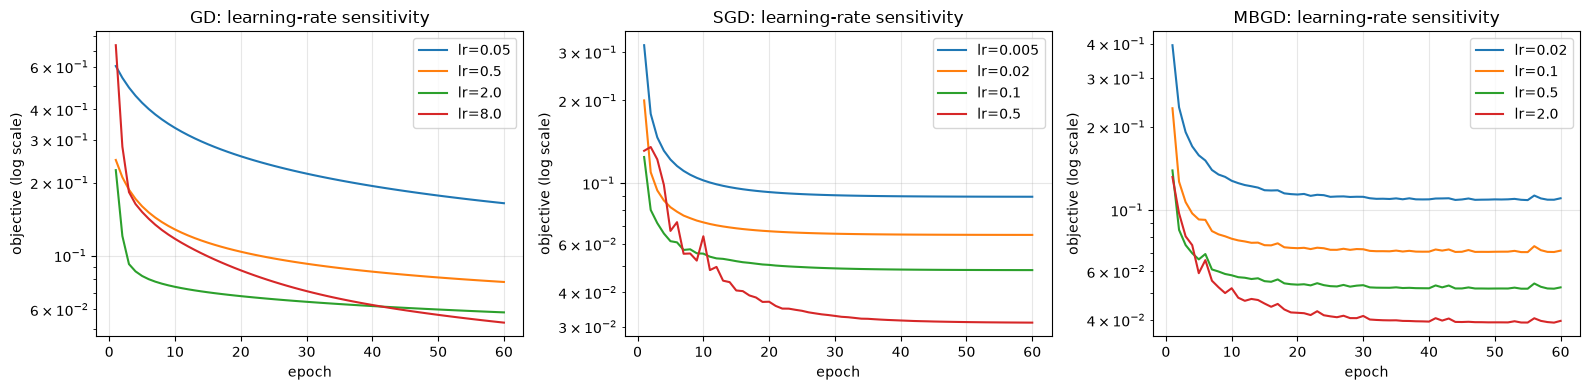

In [ ]:
final_cfg = {'GD':   dict(fn=gradient_descent, lr=best_lr, epochs=300),
             'SGD':  dict(fn=sgd,              lr=0.02,    epochs=60),
             'MBGD': dict(fn=mbgd,             lr=0.3,     epochs=100)}
rows = []
for name, cfg in final_cfg.items():
    np.random.seed(0)
    t0 = time.time()
    w, ov = quiet(cfg['fn'], x_train, y_train, best_lam, cfg['lr'], np.zeros((d, 1)), max_epoch=cfg['epochs'])
    rows.append({'method': name, 'lambda': best_lam, 'lr': cfg['lr'], 'epochs': cfg['epochs'],
                 'final objective': ov[-1],
                 'train err': error_rate(w, x_train, y_train),
                 'test err':  error_rate(w, x_test,  y_test),
                 'seconds': time.time() - t0})
display(pd.DataFrame(rows).set_index('method').round(4))

### Mini-batch size: convergence per epoch vs cost per epoch 


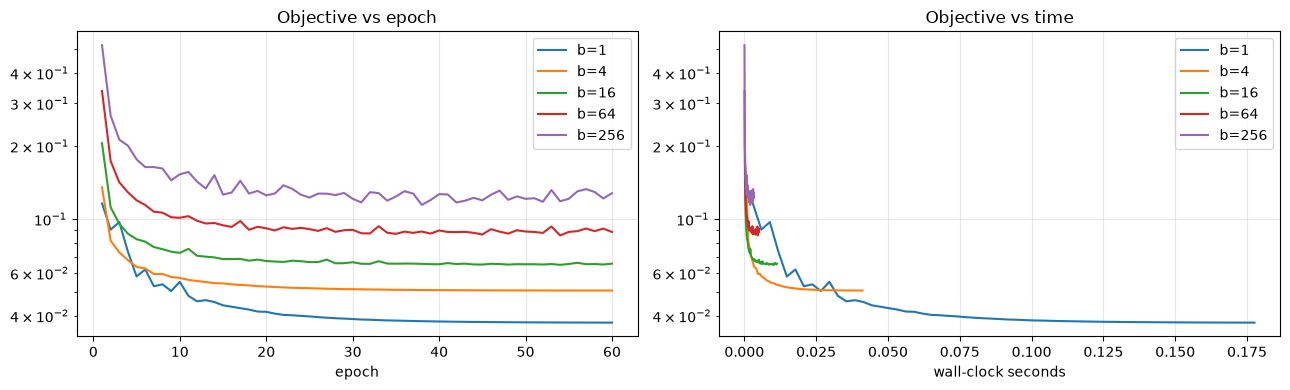

,updates/epoch,final objective,val err,seconds (60 ep)
batch size,,,,
1,364,0.0375,0.022,0.1776
4,91,0.0508,0.022,0.0411
16,23,0.0655,0.000,0.0114
64,6,0.0885,0.011,0.0051
256,2,0.1278,0.022,0.0032


In [272]:
sizes = [1, 4, 16, 64, 256]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rows = []
for b in sizes:
    batch_size = b                      # mbgd reads this module-level setting
    np.random.seed(0)
    t0 = time.time()
    w, ov = quiet(mbgd, x_fit, y_fit, best_lam, 0.3, np.zeros((d, 1)), max_epoch=60)
    secs = time.time() - t0
    axes[0].plot(np.arange(1, 61), ov, label=f'b={b}')
    axes[1].plot(np.cumsum(np.full(60, secs / 60)), ov, label=f'b={b}')
    rows.append({'batch size': b, 'updates/epoch': int(np.ceil(x_fit.shape[0] / b)),
                 'final objective': ov[-1], 'val err': error_rate(w, x_val, y_val),
                 'seconds (60 ep)': secs})
batch_size = 8                          # restore the default used in Section 3.3
axes[0].set_xlabel('epoch');        axes[0].set_title('Objective vs epoch')
axes[1].set_xlabel('wall-clock seconds'); axes[1].set_title('Objective vs time')
for ax in axes: ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index('batch size').round(4))

### Final Comparison


In [273]:
final_cfg = {'GD':   dict(fn=gradient_descent, lr=best_lr, epochs=300),
             'SGD':  dict(fn=sgd,              lr=0.02,    epochs=60),
             'MBGD': dict(fn=mbgd,             lr=0.3,     epochs=100)}
rows = []
for name, cfg in final_cfg.items():
    np.random.seed(0)
    t0 = time.time()
    w, ov = quiet(cfg['fn'], x_train, y_train, best_lam, cfg['lr'], np.zeros((d, 1)), max_epoch=cfg['epochs'])
    rows.append({'method': name, 'lambda': best_lam, 'lr': cfg['lr'], 'epochs': cfg['epochs'],
                 'final objective': ov[-1],
                 'train err': error_rate(w, x_train, y_train),
                 'test err':  error_rate(w, x_test,  y_test),
                 'seconds': time.time() - t0})
display(pd.DataFrame(rows).set_index('method').round(4))

,lambda,lr,epochs,final objective,train err,test err,seconds
method,,,,,,,
GD,0,0.50,300,0.0528,0.0110,0.0351,0.0089
SGD,0,0.02,60,0.0576,0.0132,0.0351,0.0937
MBGD,0,0.30,100,0.0517,0.0110,0.0351,0.0466


### Conclusions from parameter tuning

**Grid search over λ and learning rate** (GD, 300 epochs, selected on a validation split of the training data)
- The best setting by validation log-loss was λ = 0 with lr = 0.5 (log-loss 0.0395, validation error 0%). Validation error for λ ≤ 0.01 at lr = 0.5 was also 0%.
- Validation log-loss gets worse as λ increases at every learning rate. For example, at lr = 0.5 it is 0.0395 (λ = 0), 0.0533 (λ = 0.01), 0.113 (λ = 0.1) and 0.173 (λ = 0.3).
- lr = 0.01 is too small to converge in 300 epochs. Its validation log-loss is 0.13–0.18 for every λ, and its error stays at 3.3%.
- The validation set has only 91 samples, so one sample equals about 1.1%. Differences of one or two samples in validation error are noise, which is why log-loss was used to pick the best setting.

**Regularization parameter λ** (GD, lr = 0.5, 500 epochs, full training set)
- For λ between 0 and 0.01, training error (1.10%) and testing error (3.51%) did not change, while the weight norm ||w|| shrank from 4.14 to 2.39. Mild regularization makes the weights smaller without hurting accuracy.
- For λ = 0.1 and λ = 1, both errors increased (training 2.20% and 4.18%, testing 4.39% and 5.26%), and ||w|| dropped to 1.16 and 0.46. The penalty is so strong that the model underfits.
- The number of weights with |w| > 0.1 fell from 29 (λ ≤ 0.001) to 21 (λ = 0.1) and 8 (λ = 1), so the penalty shrinks the weak features first.
- With 455 training samples, 30 standardized features, and a train/test gap of only about 2.4 points, the unregularized model does not overfit. Regularization therefore gives no gain in test accuracy here, and the best choice is λ = 0 or a very small value (≤ 0.01).

**Learning rate** (λ = 0, 60 epochs on the fit split, objective on a log scale)
- GD: lr = 0.05 is too slow (objective 0.164 after 60 epochs, never below 0.1). lr = 0.5 gets below 0.1 at epoch 23. lr = 2.0 gets there at epoch 3 and reaches the lowest validation error (0%). lr = 8.0 overshoots (the objective jumps to 0.74 in epoch 1) and has the worst validation error among the larger rates (3.3%), even though it eventually settles near 0.053.
- SGD: lr = 0.005 is slow (objective 0.089 after 60 epochs). lr = 0.02 gives the best validation error (0%). lr = 0.5 reaches the lowest training objective (0.031) but the highest validation error (4.4%). Large single-sample steps make the final weights noisy.
- MBGD: lr = 0.02 is too slow (objective 0.110, never below 0.1). lr = 0.1 gives 0% validation error. lr = 0.5 and 2.0 converge fastest (below 0.1 by epoch 2), but their validation error is 2.2%.
- A larger learning rate converges faster, but past a point it overshoots (GD) or adds noise (SGD/MBGD). SGD and MBGD tolerate much smaller learning rates than GD because they make many more updates per epoch.

**Mini-batch size b** (MBGD, λ = 0, lr = 0.3, 60 epochs)
- Updates per epoch fall from 364 (b = 1) to 2 (b = 256), and the final objective rises from 0.038 to 0.128. Small batches converge much further per epoch.
- Small batches cost more time. b = 1 took 0.74 s, b = 16 took 0.05 s, and b = 256 took 0.008 s for 60 epochs, so b = 1 was about 90 times slower than b = 256.
- b = 16 is a good trade-off: 0% validation error, about 15 times faster than b = 1, and a final objective of 0.066.
- b = 256 makes only 2 updates per epoch and, with the learning rate decaying each epoch, behaves like slow batch GD.

**Final comparison** (tuned settings, retrained on the full training set, tested once)
- GD (lr = 0.5, 300 epochs), SGD (lr = 0.02, 60 epochs) and MBGD (lr = 0.3, 100 epochs) all reach the same test error of 3.51% (96.49% accuracy). Training error is 1.10% for GD and MBGD and 1.32% for SGD.
- Computation differs: GD needed 0.03 s, MBGD 0.20 s and SGD 0.39 s in my run. Batch GD is cheapest per epoch here, but SGD and MBGD need far fewer epochs to reach a low loss.

**Overall**
All three optimizers reach about 96.5% test accuracy at their tuned settings. The tuning mainly affects convergence speed and stability, not final accuracy. Regularization is not needed here, since λ ≤ 0.01 is harmless and larger values hurt. SGD and MBGD are more sensitive to noise at high learning rates, while GD needs a larger learning rate to converge in few epochs.